<a href="https://colab.research.google.com/github/Kodambhagath/Credit-Card-Fraud-detection/blob/main/CREDIT_CARD_FRAUD_DECTATION_STATML_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
credit_card = pd.read_csv('/content/creditcard.csv')

In [ ]:
credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit_card.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Seperating features and target veriables**

In [ ]:
X = credit_card.drop('Class', axis=1)
y = credit_card['Class']

In [ ]:
class_distrubution = y.value_counts()
print(class_distrubution)

Class
0    284315
1       492
Name: count, dtype: int64


# **Address class imbalance using undersampling**

In [ ]:
fraud = credit_card[credit_card['Class'] == 1]
non_fraud = credit_card[credit_card['Class'] == 0]

In [ ]:
non_fraud_undersampled = resample(non_fraud, replace=False, n_samples=len(fraud), random_state=42)
print(non_fraud_undersampled)

            Time        V1        V2        V3        V4        V5        V6  \
138028   82450.0  1.314539  0.590643 -0.666593  0.716564  0.301978 -1.125467   
63099    50554.0 -0.798672  1.185093  0.904547  0.694584  0.219041 -0.319295   
73411    55125.0 -0.391128 -0.245540  1.122074 -1.308725 -0.639891  0.008678   
164247  116572.0 -0.060302  1.065093 -0.987421 -0.029567  0.176376 -1.348539   
148999   90434.0  1.848433  0.373364  0.269272  3.866438  0.088062  0.970447   
...          ...       ...       ...       ...       ...       ...       ...   
121938   76376.0 -1.525978  0.796226  1.172478 -0.947111  0.077071 -1.655590   
84533    60348.0 -0.705795  1.418016  0.993756  0.908646 -0.171163 -0.566892   
55840    47151.0  0.995185 -0.147746 -0.108914  1.168451  0.329676  1.182090   
70411    53857.0 -1.197741  3.166857 -3.476764  0.818768  1.310580 -0.445066   
95640    65405.0 -0.558983 -0.431438  1.893696 -1.783053 -1.752650  0.522665   

              V7        V8        V9  .

### **Combining the undersampled non-fraud data with the fraud data**

In [ ]:
balanced_data = pd.concat([fraud, non_fraud_undersampled])
print(balanced_data)

           Time        V1        V2        V3        V4        V5        V6  \
541       406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623       472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920     4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108     6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329     7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
...         ...       ...       ...       ...       ...       ...       ...   
121938  76376.0 -1.525978  0.796226  1.172478 -0.947111  0.077071 -1.655590   
84533   60348.0 -0.705795  1.418016  0.993756  0.908646 -0.171163 -0.566892   
55840   47151.0  0.995185 -0.147746 -0.108914  1.168451  0.329676  1.182090   
70411   53857.0 -1.197741  3.166857 -3.476764  0.818768  1.310580 -0.445066   
95640   65405.0 -0.558983 -0.431438  1.893696 -1.783053 -1.752650  0.522665   

              V7        V8        V9  ...       V21

**Split the balanced data into features and target variable**

In [ ]:
X_balanced = balanced_data.drop('Class', axis=1)
y_balanced = balanced_data['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

**Standardizing the features**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Displaying the balanced class distribution of credit card data**

In [ ]:
balanced_class_distrubution = y_balanced.value_counts()
balanced_class_distrubution

,count
Class,
1,492
0,492


#**Logistic regression model**

In [ ]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train.to_numpy())
y_pred_logistic = logistic_regression.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(accuracy_logistic)

0.9459459459459459


In [ ]:
report_logistic = classification_report(y_test, y_pred_logistic)
print(report_logistic)

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       146
           1       0.99      0.90      0.94       150

    accuracy                           0.95       296
   macro avg       0.95      0.95      0.95       296
weighted avg       0.95      0.95      0.95       296



In [ ]:
confusion_matrix_logistic = pd.crosstab(y_test, y_pred_logistic)
confusion_matrix_logistic

col_0,0,1
Class,,
0,145,1
1,15,135


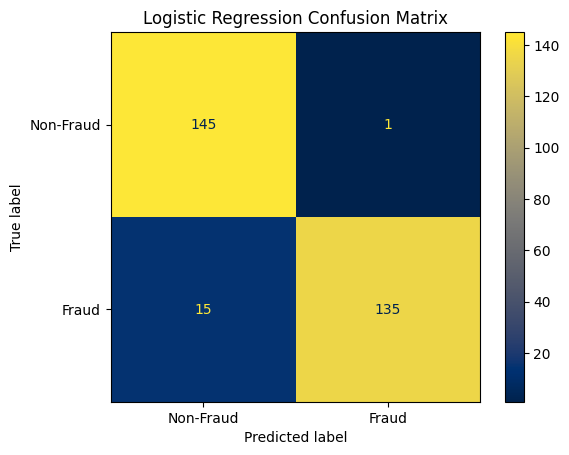

In [ ]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
ConfusionMatrixDisplay(cm_logistic, display_labels=["Non-Fraud", "Fraud"]).plot(cmap='cividis')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# **SVM**

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [ ]:
report_svm = classification_report(y_test, y_pred_svm)
print(report_svm)

              precision    recall  f1-score   support

           0       0.83      0.99      0.91       146
           1       0.99      0.81      0.89       150

    accuracy                           0.90       296
   macro avg       0.91      0.90      0.90       296
weighted avg       0.91      0.90      0.90       296



In [ ]:
confusion_matrix_svm = pd.crosstab(y_test, y_pred_svm)
confusion_matrix_svm

col_0,0,1
Class,,
0,145,1
1,29,121


In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(accuracy_svm)

0.8986486486486487


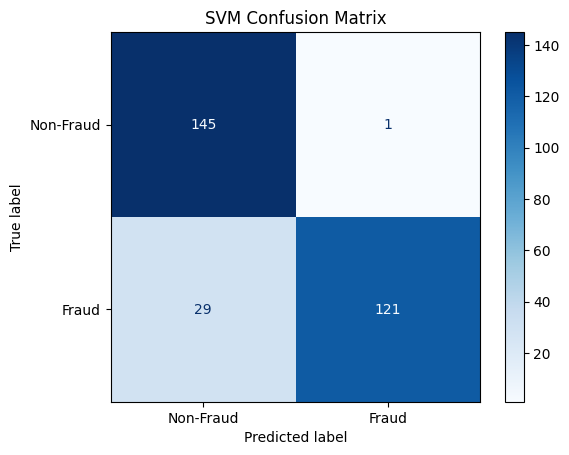

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=["Non-Fraud", "Fraud"]).plot(cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()

# **Perceptron**

In [ ]:
perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train)
y_pred_perceptron = perceptron_model.predict(X_test)
report_perceptron = classification_report(y_test, y_pred_perceptron)
print(report_perceptron)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       146
           1       0.51      1.00      0.67       150

    accuracy                           0.51       296
   macro avg       0.25      0.50      0.34       296
weighted avg       0.26      0.51      0.34       296



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
confusion_matrix_perceptron = pd.crosstab(y_test, y_pred_perceptron)
confusion_matrix_perceptron

col_0,1
Class,
0,146
1,150


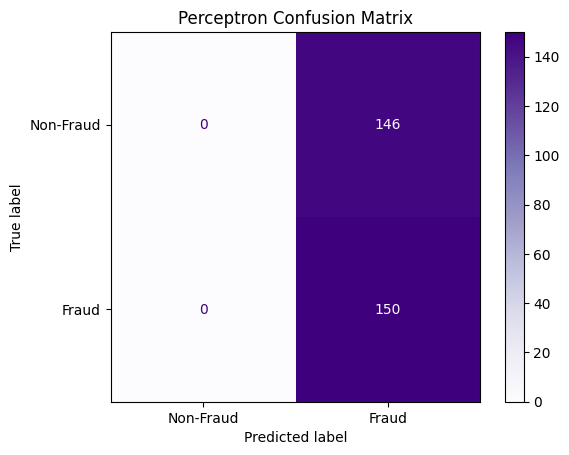

In [ ]:
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)
ConfusionMatrixDisplay(cm_perceptron, display_labels=["Non-Fraud", "Fraud"]).plot(cmap='Purples')
plt.title("Perceptron Confusion Matrix")
plt.show()


In [ ]:
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(accuracy_perceptron)

0.5067567567567568


#**KNN**

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(X_test)
report_knn = classification_report(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(accuracy_knn)

0.6486486486486487


In [ ]:
print(report_knn)

              precision    recall  f1-score   support

           0       0.64      0.66      0.65       146
           1       0.66      0.63      0.65       150

    accuracy                           0.65       296
   macro avg       0.65      0.65      0.65       296
weighted avg       0.65      0.65      0.65       296



In [ ]:
confusion_matrix_knn = pd.crosstab(y_test, y_pred_knn)
print(confusion_matrix_knn)

col_0   0   1
Class        
0      97  49
1      55  95


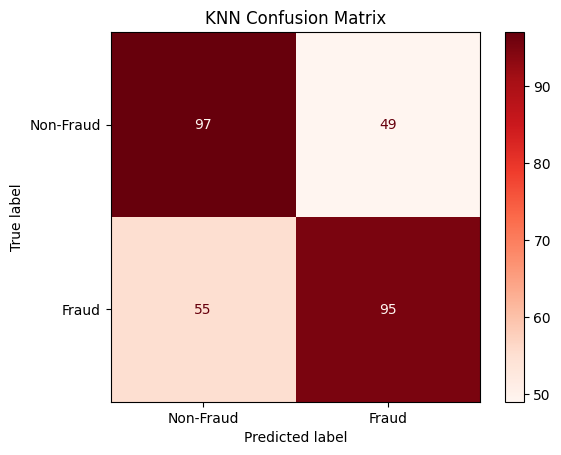

In [ ]:
# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Non-Fraud", "Fraud"]).plot(cmap='Reds')
plt.title("KNN Confusion Matrix")
plt.show()
